# Finetuning Architecture Diagrams

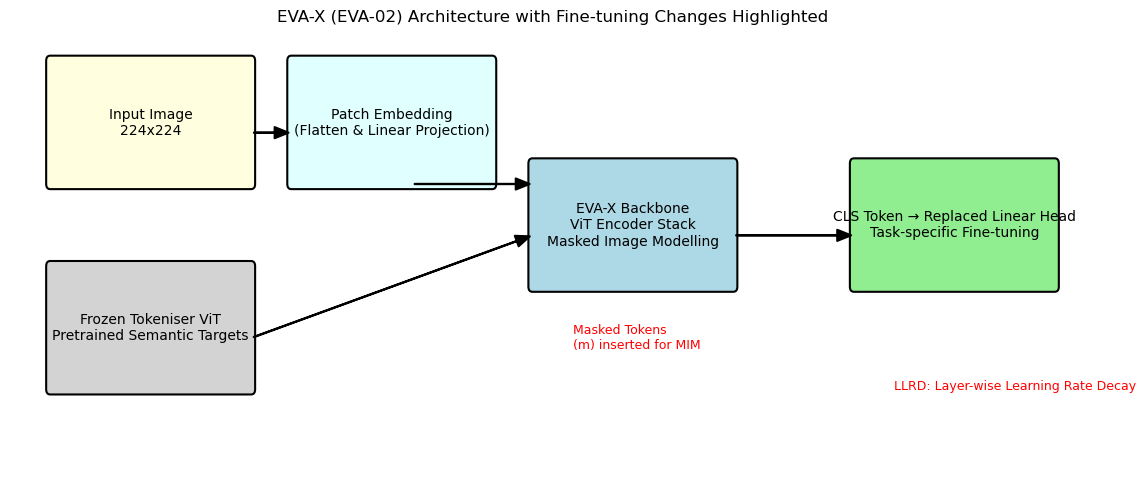

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, ArrowStyle

def draw_box(ax, xy, text, width=2.5, height=1.2, color="lightblue"):
    box = FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.05",
        edgecolor="black",
        facecolor=color,
        linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width/2,
        xy[1] + height/2,
        text,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True
    )

def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle=ArrowStyle("Simple", head_length=10, head_width=8),
        linewidth=1.5,
        color="black"
    )
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(14,6))

# Input image
draw_box(ax, (0,2.5), "Input Image\n224x224", color="lightyellow")

# Patch embedding
draw_box(ax, (3,2.5), "Patch Embedding\n(Flatten & Linear Projection)", color="lightcyan")

# Frozen Tokeniser
draw_box(ax, (0,0.5), "Frozen Tokeniser ViT\nPretrained Semantic Targets", color="lightgrey")

# EVA-X Backbone (ViT blocks)
draw_box(ax, (6,1.5), "EVA-X Backbone\nViT Encoder Stack\nMasked Image Modelling", color="lightblue")

# CLS token → replaced head
draw_box(ax, (10,1.5), "CLS Token → Replaced Linear Head\nTask-specific Fine-tuning", color="lightgreen")

# Mask token annotation
ax.text(6.5, 0.9, "Masked Tokens\n(m) inserted for MIM", fontsize=9, color="red")

# LLRD annotation
ax.text(10.5,0.5,"LLRD: Layer-wise Learning Rate Decay", fontsize=9, color="red")

# Arrows
draw_arrow(ax, (2.5,3), (3,3))    # Image → PatchEmbed
draw_arrow(ax, (4.5,2.5), (6,2.5)) # PatchEmbed → Backbone
draw_arrow(ax, (2.5,1), (6,2))     # Tokeniser → Backbone
draw_arrow(ax, (8.5,2), (10,2))    # Backbone → Head

# Formatting
ax.set_xlim(-0.5, 13)
ax.set_ylim(-0.5, 4)
ax.axis("off")
plt.title("EVA-X (EVA-02) Architecture with Fine-tuning Changes Highlighted", fontsize=12)
plt.show()

# Sex & Age Prediction

## Class Imbalance

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_data(age_path, sex_path, split_name):
    # Load age: skip first column (filename), name the second 'Age'
    age_df = pd.read_csv(age_path, sep=' ', header=None, usecols=[1], names=['Age'])
    
    # Load sex: skip first column, use columns 1 and 2 for one-hot encoding
    sex_df = pd.read_csv(sex_path, sep=' ', header=None, usecols=[1, 2])
    
    # Convert one-hot [1, 0] to 'Male' and [0, 1] to 'Female'
    # Using .idxmax(axis=1) picks the column index with the '1'
    sex_labels = sex_df.idxmax(axis=1).map({1: 'Male', 2: 'Female'})
    
    df = pd.DataFrame({'Age': age_df['Age'], 'Sex': sex_labels})
    df['Split'] = split_name
    return df

# Combine all sets
splits = [
    load_data('~/EVA-X/regression/datasets/data_splits/cxr14/age_labels_train.txt', 
              '~/EVA-X/classification/datasets/data_splits/cxr14/sex_labels_train.txt', 'Train'),
    load_data('~/EVA-X/regression/datasets/data_splits/cxr14/age_labels_test.txt', 
              '~/EVA-X/classification/datasets/data_splits/cxr14/sex_labels_test.txt', 'Test'),
    load_data('~/EVA-X/regression/datasets/data_splits/cxr14/age_labels_val.txt', 
              '~/EVA-X/classification/datasets/data_splits/cxr14/sex_labels_val.txt', 'Validation'),
]
full_df = pd.concat(splits, ignore_index=True)
filter_df = full_df[full_df['Age'] <= 100]
full_df

,Age,Sex,Split
0,58,Male,Train
1,58,Male,Train
2,58,Male,Train
3,81,Male,Train
4,82,Male,Train
...,...,...,...
112115,68,Female,Validation
112116,26,Female,Validation
112117,26,Female,Validation
112118,26,Female,Validation


In [3]:
full_df.describe()

,Age
count,112120.000000
mean,46.901463
std,16.839923
min,1.000000
25%,35.000000
50%,49.000000
75%,59.000000
max,414.000000


In [4]:
full_df.groupby('Split').describe()

Age                                                    
              count       mean        std  min   25%   50%   75%    max
Split                                                                  
Test        25596.0  47.007579  16.854982  1.0  34.0  49.0  59.0  414.0
Train       75312.0  46.837370  16.865942  1.0  35.0  49.0  59.0  413.0
Validation  11212.0  47.089725  16.628140  2.0  35.0  49.0  59.0  155.0

In [5]:
full_df['Age'].median()

49.0

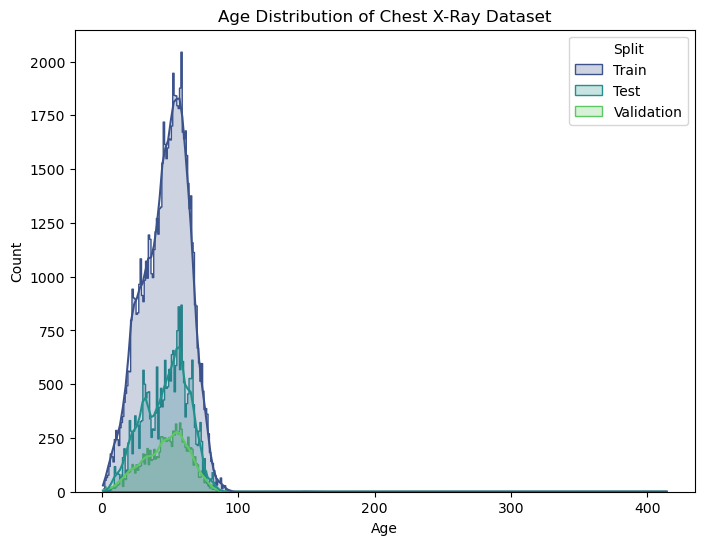

In [6]:
plt.figure(figsize=(8, 6))
sns.histplot(data=full_df, x='Age', hue='Split', kde=True, element="step", palette='viridis')
plt.title('Age Distribution of Chest X-Ray Dataset')
plt.show()

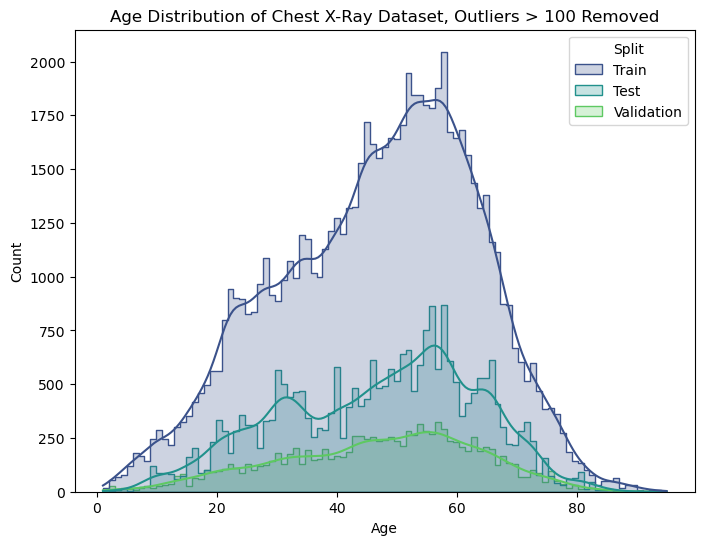

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(data=filter_df, x='Age', hue='Split', kde=True, element="step", palette='viridis')
plt.title('Age Distribution of Chest X-Ray Dataset, Outliers > 100 Removed')
plt.savefig('age_distribution.pdf', dpi=300)
plt.show()

In [8]:
import scipy.stats as stats
splits = filter_df['Split'].unique()

for split in splits:
    ages = filter_df[filter_df['Split'] == split]['Age']
    # --- Skewness and Kurtosis ---
    skewness = stats.skew(ages)
    kurtosis = stats.kurtosis(ages)  # excess kurtosis
    print(f"{split} Skewness: {skewness:.4f}")
    print(f"{split} Excess Kurtosis: {kurtosis:.4f}")

    # --- Shapiro-Wilk Test ---
    # Note: Shapiro-Wilk is limited to 5000 samples, so we sample if needed
    if len(ages) > 5000:
        sample = ages.sample(5000, random_state=42)
    else:
        sample = ages

    shapiro_test = stats.shapiro(sample)
    print(f"{split} Shapiro-Wilk Test statistic: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

    if shapiro_test.pvalue > 0.05:
        print("Fail to reject null hypothesis: data could be normally distributed")
    else:
        print("Reject null hypothesis: data is likely not normally distributed")

Train Skewness: -0.2871
Train Excess Kurtosis: -0.4986
Train Shapiro-Wilk Test statistic: 0.9853, p-value: 0.0000
Reject null hypothesis: data is likely not normally distributed
Test Skewness: -0.2704
Test Excess Kurtosis: -0.6760
Test Shapiro-Wilk Test statistic: 0.9805, p-value: 0.0000
Reject null hypothesis: data is likely not normally distributed
Validation Skewness: -0.3067
Validation Excess Kurtosis: -0.4910
Validation Shapiro-Wilk Test statistic: 0.9856, p-value: 0.0000
Reject null hypothesis: data is likely not normally distributed


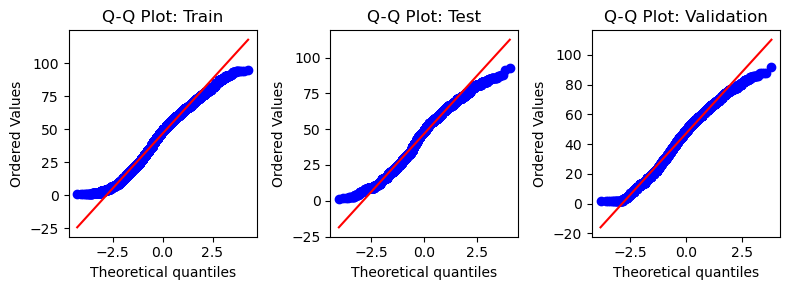

In [9]:
# Set up plot grid
fig, axes = plt.subplots(1, len(splits), figsize=(8, 3))

# If only one split, axes might not be a list
if len(splits) == 1:
    axes = [axes]

for ax, split in zip(axes, splits):
    data = filter_df[filter_df['Split'] == split]['Age']
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {split}')

plt.tight_layout()
plt.savefig('age_q_q_plots.pdf', dpi=300)
plt.show()

/tmp/ipykernel_83203/654582684.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


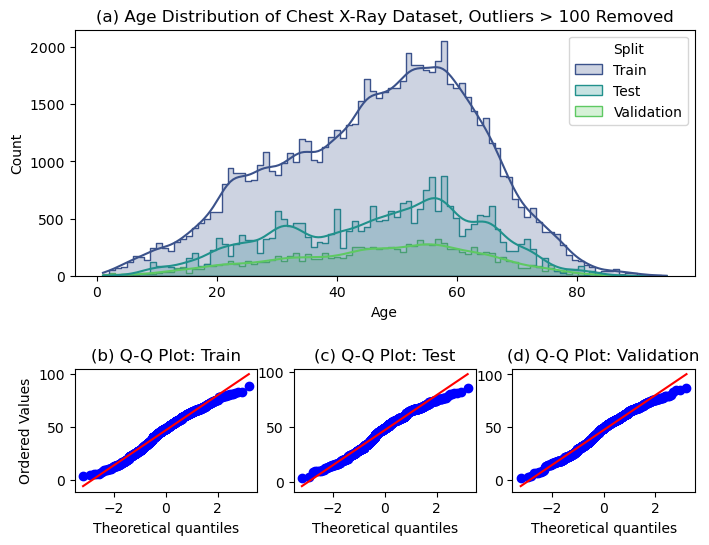

In [10]:
# Create figure with 2 rows
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, max(3, len(splits)), height_ratios=[2, 1], hspace=0.5)

# --- Row 1: Histogram spanning all columns ---
ax_hist = fig.add_subplot(gs[0, :])
sns.histplot(
    data=filter_df,
    x='Age',
    hue='Split',
    kde=True,
    element="step",
    palette='viridis',
    ax=ax_hist
)
ax_hist.set_title('(a) Age Distribution of Chest X-Ray Dataset, Outliers > 100 Removed')

# --- Row 2: Q-Q plots ---
sample_size = 1000
alphabet = ['b', 'c', 'd']
for i, split in enumerate(splits):
    ax_qq = fig.add_subplot(gs[1, i])
    data = filter_df[filter_df['Split'] == split]['Age']
    
    # Sample if dataset is larger than sample_size
    if len(data) > sample_size:
        data = data.sample(sample_size, random_state=42)
    
    stats.probplot(data, dist="norm", plot=ax_qq)
    
    if i > 0:
        ax_qq.set_ylabel('')
        
    ax_qq.set_title(f'({alphabet[i]}) Q-Q Plot: {split}')

plt.tight_layout()
plt.savefig('age_combined_plots.pdf', dpi=300)
plt.show()

In [11]:
full_df.groupby(['Sex', 'Split']).describe()

Age                                                    
                     count       mean        std  min   25%   50%   75%    max
Sex    Split                                                                  
Female Test        10714.0  47.939238  16.027907  2.0  37.0  49.0  59.0  152.0
       Train       33152.0  46.139177  16.367364  1.0  35.0  48.0  58.0  413.0
       Validation   4914.0  46.005495  16.435249  2.0  34.0  47.0  57.0  151.0
Male   Test        14882.0  46.336850  17.395799  1.0  32.0  49.0  59.0  414.0
       Train       42160.0  47.386385  17.228204  1.0  35.0  50.0  60.0  412.0
       Validation   6298.0  47.935694  16.729665  2.0  36.0  50.0  60.0  155.0

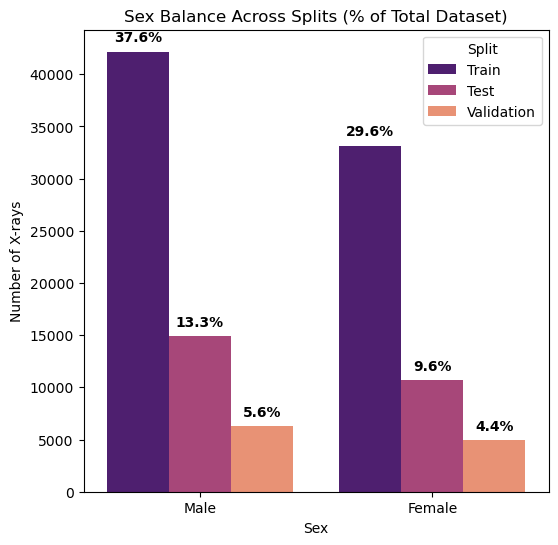

In [12]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=full_df, x='Sex', hue='Split', palette='magma')

# Calculate the total number of samples for the percentage denominator
total = len(full_df)

for p in ax.patches:
    height = p.get_height()
    if height > 0: # Avoid labeling empty bars
        percentage = f'{100 * height / total:.1f}%'
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontweight='bold')

plt.title('Sex Balance Across Splits (% of Total Dataset)')
plt.ylabel('Number of X-rays')
plt.savefig('age_sex_total_balance.pdf', dpi=300)
plt.show()

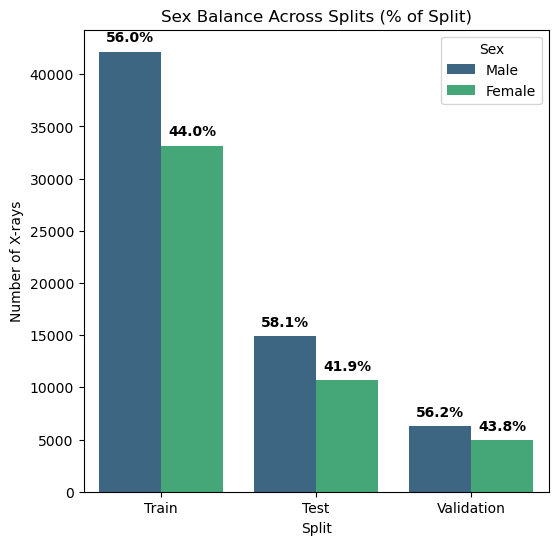

In [13]:
plt.figure(figsize=(6, 6))

ax = sns.countplot(data=full_df, x='Split', hue='Sex', palette='viridis')

# 1. Get the total counts for each split (the denominator)
split_counts = full_df.groupby('Split').size().to_dict()

# 2. Get the labels from the X-axis to match the index to the name
# e.g., {0: 'Train', 1: 'Test', 2: 'Eval'}
labels = [l.get_text() for l in ax.get_xticklabels()]

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # p.get_x() gives the left edge. Adding half-width gives the center.
        # Rounding/Casting to int gives us the index (0, 1, or 2)
        idx = int(round(p.get_x() + p.get_width() / 2.))
        current_split = labels[idx]
        
        # Calculate percentage relative to THAT split's total
        total_for_this_split = split_counts[current_split]
        percentage = f'{100 * height / total_for_this_split:.1f}%'
        
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontweight='bold',
                    fontsize=10)

plt.title('Sex Balance Across Splits (% of Split)')
plt.ylabel('Number of X-rays')
plt.savefig('age_sex_split_balance.pdf', dpi=300)
plt.show()

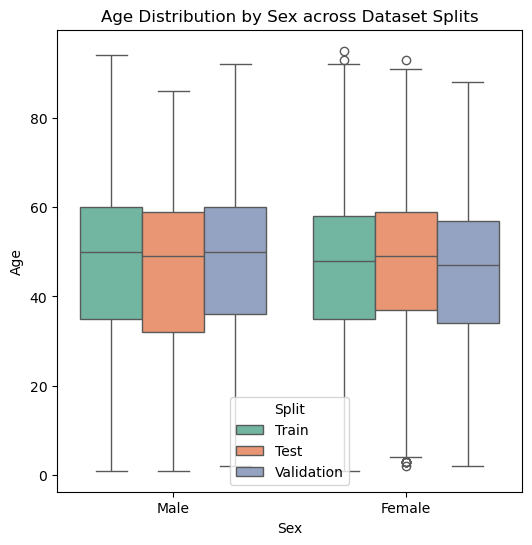

In [14]:
plt.figure(figsize=(6, 6))
ax = sns.boxplot(data=filter_df, x='Sex', y='Age', hue='Split', palette='Set2')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Train', 'Test', 'Validation'], title='Split', loc='lower center')

plt.title('Age Distribution by Sex across Dataset Splits')
plt.savefig('age_sex_boxplot.pdf', dpi=300)

## Sex Results

In [32]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


models = {
    'eva_x_ti': 'EVA-X Tiny (Log. Reg)',
    'eva_x_ti_huber': 'EVA-X Tiny (Huber Loss)',
    'resnet': 'Resnet 50 CNN',
    'eva_x_base_linear': 'EVA-X Base (Log. Reg.)',
    'eva_x_base_mlp': 'EVA-X Base (MLP)',
    'eva_x_sm_linear': 'EVA-X Small (Log. Reg.)',
    'eva_x_ti_linear': 'EVA-X Tiny (Log. Reg.)',
    'eva_x_ti_mlp': 'EVA-X Tiny (MLP)',
    'resnet50_no_sigmoid': 'Resnet 50 CNN'
}
AGE_STD_DEV = 16.60267981756069

def load_from_logs(path, is_age_regression=False):
    global models
    global AGE_STD_DEV

    # --------- DIRECTORY CONTAINING LOG FILES ----------
    log_dir = Path(path)   # change to your directory
    # ----------------------------------------------------

    def load_log(path):
        print(f"Loading {path}")
        records = []
        with open(path, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
                    
        df = pd.DataFrame(records)
        
        # Expand any list columns
        for col in df.columns:
            first_valid = df[col].dropna().iloc[0] if not df[col].dropna().empty else None

            if isinstance(first_valid, list):
                # Expand the list into new columns named 'col_0', 'col_1', etc.
                expanded_cols = pd.DataFrame(df[col].tolist(), index=df.index).add_prefix(f'{col}_')
                # Join back to main DF and drop the original list column
                df = pd.concat([df, expanded_cols], axis=1).drop(columns=[col])
                
        df = df.drop_duplicates()
        df = df.sort_values("epoch")
        return df


    # --------- Automatically collect all .txt files ----------
    log_files = sorted(log_dir.glob("*.txt"))

    if not log_files:
        raise ValueError(f"No .txt files found in {log_dir}")

    # --------- Combine all logs ----------
    all_dfs = []
    for path in log_files:
        df = load_log(path)
        df["Model"] = models[path.stem] if path.stem in models else path.stem   # filename (without .txt) as run label
        all_dfs.append(df)

    df_all = pd.concat(all_dfs, ignore_index=True)
    if is_age_regression:
        df_all['test_mae'] = df_all['test_mae'] * AGE_STD_DEV
        df_all['test_rmse'] = df_all['test_rmse'] * AGE_STD_DEV
    return df_all

In [33]:
df_all = load_from_logs('logs/sex')
df_all

Loading logs/sex/eva_x_ti.txt
Loading logs/sex/resnet.txt


,train_lr,train_loss,test_loss,test_auc_avg,epoch,n_parameters,test_auc_each_class_0,test_auc_each_class_1,Model
0,0.000099,0.634083,0.277415,0.967436,0,5525570,0.967433,0.967438,EVA-X Tiny (Log. Reg)
1,0.001000,0.244799,0.098127,0.993831,5,5525570,0.993827,0.993835,EVA-X Tiny (Log. Reg)
2,0.001000,0.201618,0.084899,0.995331,10,5525570,0.995324,0.995338,EVA-X Tiny (Log. Reg)
3,0.001000,0.183266,0.079156,0.996026,15,5525570,0.996007,0.996044,EVA-X Tiny (Log. Reg)
4,0.001000,0.170031,0.106087,0.995490,20,5525570,0.995474,0.995506,EVA-X Tiny (Log. Reg)
5,0.000100,0.353891,0.147262,0.986487,0,23512130,0.986527,0.986447,Resnet 50 CNN
6,0.001000,0.226655,0.159978,0.984926,5,23512130,0.984931,0.984922,Resnet 50 CNN
7,0.001000,0.196043,0.170808,0.988766,10,23512130,0.988765,0.988768,Resnet 50 CNN
8,0.001000,0.180186,0.112540,0.992283,15,23512130,0.992286,0.992281,Resnet 50 CNN
9,0.001000,0.172997,0.148543,0.990229,20,23512130,0.990243,0.990215,Resnet 50 CNN


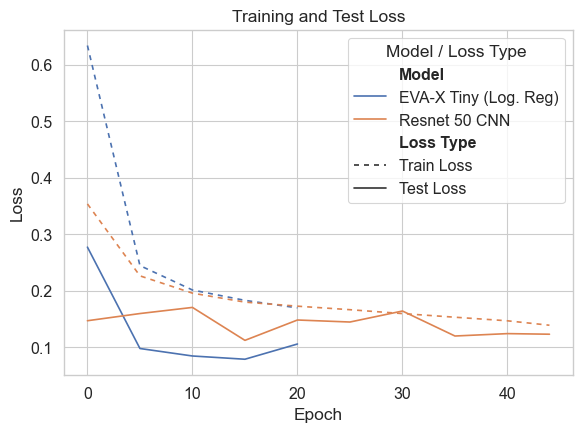

In [34]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)

df_all['Train Loss'] = df_all['train_loss']
df_all['Test Loss'] = df_all['test_loss']

# --------- Reshape data ----------
df_plot = df_all.melt(
    id_vars=["epoch", "Model"],
    value_vars=["Train Loss", "Test Loss"],
    var_name="Loss Type",
    value_name="Loss"
)

# --------- Map line styles ----------
line_styles = {"Train Loss": (3, 3), "Test Loss": ()}  # dotted vs solid

plt.figure(figsize=(6, 4.5))
sns.lineplot(
    data=df_plot,
    x="epoch",
    y="Loss",
    hue="Model",
    style="Loss Type",
    dashes=line_styles,
    markers=False
)

plt.title("Training and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
legend = plt.legend(title="Model / Loss Type", loc="upper right")
for text in legend.get_texts():
    if text.get_text() in ["Model", "Loss Type"]:
        text.set_fontweight("bold")
plt.tight_layout()
plt.savefig("sex_loss.pdf", dpi=300, bbox_inches="tight")
plt.show()

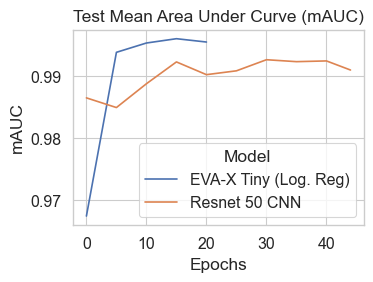

In [35]:
plt.figure(figsize=(4,3))


# MAE
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_auc_avg",
    hue="Model",
    legend=True
)
plt.title("Test Mean Area Under Curve (mAUC)")
plt.ylabel("mAUC")
plt.xlabel("Epochs")

plt.tight_layout()
plt.savefig("auc.pdf", dpi=300, bbox_inches="tight")
plt.show()

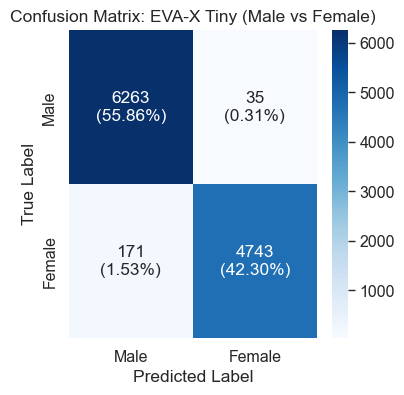

In [36]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true_raw = np.load('logs/sex/y_gt_eva.npy')    # Shape is (N, 2)
y_probs_raw = np.load('logs/sex/y_pred_eva.npy') # Shape is (N, 2)

# 1. Process data (0=Male, 1=Female)
y_true = np.argmax(y_true_raw, axis=1)
y_pred = np.argmax(y_probs_raw, axis=1)
cm = confusion_matrix(y_true, y_pred)

# 2. Create labels with Counts and Percentages
# We flatten the matrix and calculate percentages of the whole
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# 3. Plot
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
            xticklabels=['Male', 'Female'], 
            yticklabels=['Male', 'Female'])

plt.title('Confusion Matrix: EVA-X Tiny (Male vs Female)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('sex_confusion_eva_x.pdf')
plt.show()

In [37]:
# Generate the report
report = classification_report(y_true, y_pred, target_names=['Male', 'Female'])
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        Male       0.97      0.99      0.98      6298
      Female       0.99      0.97      0.98      4914

    accuracy                           0.98     11212
   macro avg       0.98      0.98      0.98     11212
weighted avg       0.98      0.98      0.98     11212



In [38]:
def calculate_ece(y_true_one_hot, y_probs_raw, n_bins=10):
    # 1. Convert to 1D: Get the actual label and the probability of the predicted class
    y_true = np.argmax(y_true_one_hot, axis=1)
    y_pred = np.argmax(y_probs_raw, axis=1)
    confidences = np.max(y_probs_raw, axis=1)
    
    # 2. Setup bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    
    for i in range(n_bins):
        # Find indices of predictions falling into this bin (Bm)
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i+1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin) # |Bm| / N
        
        if prop_in_bin > 0:
            # Accuracy in bin: average of correct predictions
            accuracy_in_bin = np.mean(y_true[in_bin] == y_pred[in_bin])
            # Confidence in bin: average of predicted probabilities
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            
            # ECE summation logic
            ece += prop_in_bin * np.abs(accuracy_in_bin - avg_confidence_in_bin)
            
    return ece

ece_value = calculate_ece(y_true_raw, y_probs_raw)
print(f"EVA-X-Ti Expected Calibration Error (ECE): {ece_value:.4f}")

EVA-X-Ti Expected Calibration Error (ECE): 0.0060


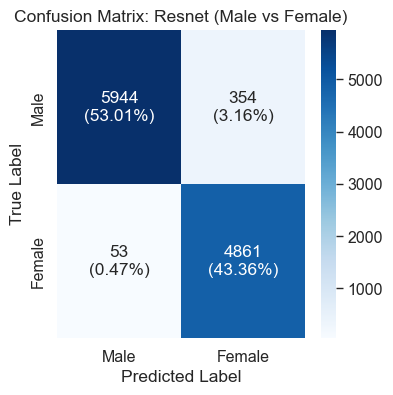

In [39]:
y_true_raw = np.load('logs/sex/y_gt_resnet.npy')    # Shape is (N, 2)
y_probs_raw = np.load('logs/sex/y_pred_resnet.npy') # Shape is (N, 2)

# 1. Process data (0=Male, 1=Female)
y_true = np.argmax(y_true_raw, axis=1)
y_pred = np.argmax(y_probs_raw, axis=1)
cm = confusion_matrix(y_true, y_pred)

# 2. Create labels with Counts and Percentages
# We flatten the matrix and calculate percentages of the whole
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# 3. Plot
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
            xticklabels=['Male', 'Female'], 
            yticklabels=['Male', 'Female'])

plt.title('Confusion Matrix: Resnet (Male vs Female)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('sex_confusion_resnet.pdf')
plt.show()

In [40]:
# Generate the report
report = classification_report(y_true, y_pred, target_names=['Male', 'Female'])
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        Male       0.99      0.94      0.97      6298
      Female       0.93      0.99      0.96      4914

    accuracy                           0.96     11212
   macro avg       0.96      0.97      0.96     11212
weighted avg       0.97      0.96      0.96     11212



In [41]:
ece_value = calculate_ece(y_true_raw, y_probs_raw)
print(f"Resnet Expected Calibration Error (ECE): {ece_value:.4f}")

Resnet Expected Calibration Error (ECE): 0.0082


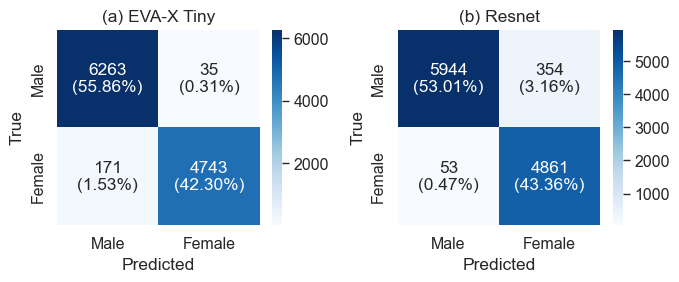

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Load data for EVA-X Tiny ---
y_true_raw = np.load('logs/sex/y_gt_eva.npy')
y_probs_raw = np.load('logs/sex/y_pred_eva.npy')
y_true_eva = np.argmax(y_true_raw, axis=1)
y_pred_eva = np.argmax(y_probs_raw, axis=1)
cm_eva = confusion_matrix(y_true_eva, y_pred_eva)

labels_eva = np.array([
    f"{v1}\n({v2:.2%})" 
    for v1, v2 in zip(cm_eva.flatten(), cm_eva.flatten()/np.sum(cm_eva))
]).reshape(2,2)

# --- Load data for Resnet ---
y_true_raw = np.load('logs/sex/y_gt_resnet.npy')
y_probs_raw = np.load('logs/sex/y_pred_resnet.npy')
y_true_res = np.argmax(y_true_raw, axis=1)
y_pred_res = np.argmax(y_probs_raw, axis=1)
cm_res = confusion_matrix(y_true_res, y_pred_res)

labels_res = np.array([
    f"{v1}\n({v2:.2%})" 
    for v1, v2 in zip(cm_res.flatten(), cm_res.flatten()/np.sum(cm_res))
]).reshape(2,2)

# --- Plot both matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(7, 3))  # compact figure

sns.heatmap(cm_eva, annot=labels_eva, fmt='', cmap='Blues', 
            xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'],
            ax=axes[0])
axes[0].set_title('(a) EVA-X Tiny')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_res, annot=labels_res, fmt='', cmap='Blues', 
            xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'],
            ax=axes[1])
axes[1].set_title('(b) Resnet')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('sex_confusion_comparison.pdf')
plt.show()

In [43]:
def get_model_summary(group):
    # Sort by epoch to ensure we get the true final row
    group = group.sort_values('epoch')
    
    final_row = group.iloc[-1]
    best_row = group.loc[group['test_auc_avg'].idxmin()]
    
    return pd.Series({
        'Final_AUC_Avg': final_row['test_auc_avg'],
        'Best_AUC_Avg': best_row['test_auc_avg'],
        'Best_Epoch_AUC': best_row['epoch']
    })

# Apply the function to each model group
summary_df = df_all.groupby('Model').apply(get_model_summary).sort_values('Final_AUC_Avg', ascending=False).reset_index()

summary_df

,Model,Final_AUC_Avg,Best_AUC_Avg,Best_Epoch_AUC
0,EVA-X Tiny (Log. Reg),0.995490,0.967436,0.0
1,Resnet 50 CNN,0.990977,0.984926,5.0


In [55]:
# ReXGradient results
y_true_raw = np.load('logs/sex/y_gt_eva_rexgrad.npy')
y_probs_raw = np.load('logs/sex/y_pred_eva_rexgrad.npy')
calculate_ece(y_true_raw, y_probs_raw)

0.05024356118550012

In [56]:
# ReXGradient results
y_true_raw = np.load('logs/sex/y_gt_resnet_rexgrad.npy')
y_probs_raw = np.load('logs/sex/y_pred_resnet_rexgrad.npy')
calculate_ece(y_true_raw, y_probs_raw)

0.03432876383204858

## Age Results

In [44]:
df_all = load_from_logs('logs/age', is_age_regression=True)
df_all.head(5)

Loading logs/age/eva_x_base_linear.txt
Loading logs/age/eva_x_base_mlp.txt
Loading logs/age/eva_x_sm_linear.txt
Loading logs/age/eva_x_ti_huber.txt
Loading logs/age/eva_x_ti_linear.txt
Loading logs/age/eva_x_ti_mlp.txt
Loading logs/age/resnet50_no_sigmoid.txt


,train_lr,train_loss,test_loss,test_mae,test_mse,test_rmse,epoch,n_parameters,Model
0,0.000100,0.609895,0.251118,5.770393,0.251137,8.320204,0,85851649,EVA-X Base (Log. Reg.)
1,0.000999,0.253976,0.197110,4.944571,0.197128,7.371431,5,85851649,EVA-X Base (Log. Reg.)
2,0.000954,0.219262,0.181668,4.653549,0.181687,7.076851,10,85851649,EVA-X Base (Log. Reg.)
3,0.000840,0.194059,0.216811,5.283303,0.216829,7.731024,15,85851649,EVA-X Base (Log. Reg.)
4,0.000673,0.183513,0.184199,4.657530,0.184217,7.125961,20,85851649,EVA-X Base (Log. Reg.)


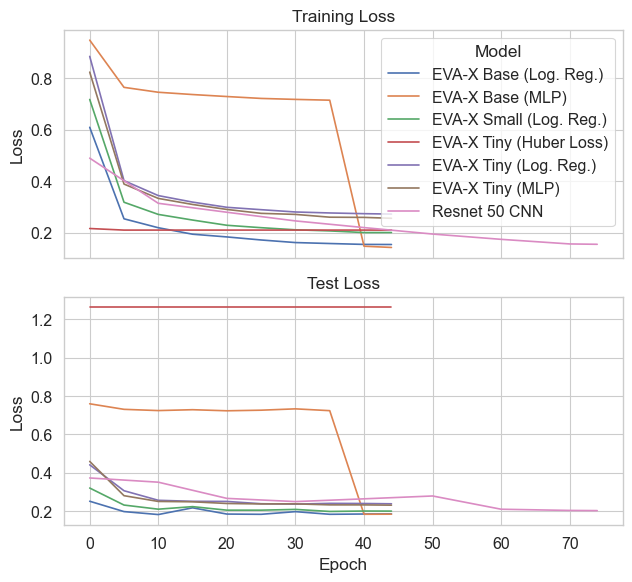

In [49]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)

# --------- Create subplots ----------
fig, axes = plt.subplots(
    2, 1,
    figsize=(6.5, 6),
    sharex=True
)

# --------- Train subplot ----------
sns.lineplot(
    data=df_all,
    x="epoch",
    y="train_loss",
    hue="Model",
    ax=axes[0],
    legend=True,
    errorbar=None
)
axes[0].set_title("Training Loss")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("")
#axes[0].set_yscale('log')

# --------- Test subplot ----------
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_loss",
    hue="Model",
    ax=axes[1],
    legend=False,
    errorbar=None
)
axes[1].set_title("Test Loss")
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Epoch")
#axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("age_loss.pdf", dpi=300, bbox_inches="tight")
plt.show()

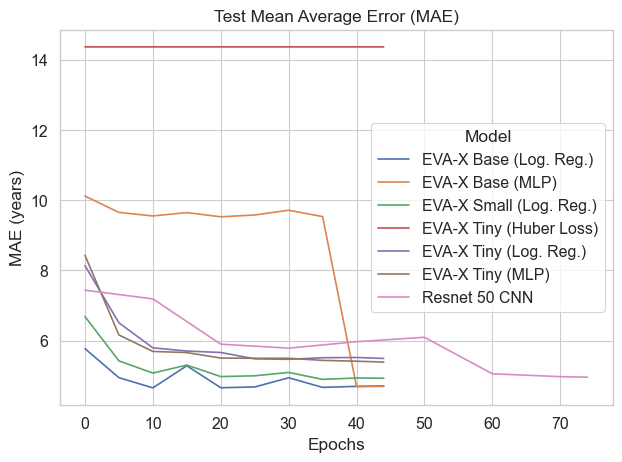

In [50]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)


# MAE
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_mae",
    hue="Model",
    legend=True,
    errorbar=None
)
plt.title("Test Mean Average Error (MAE)")
plt.ylabel("MAE (years)")
plt.xlabel("Epochs")

plt.tight_layout()
plt.savefig("mae.pdf", dpi=300, bbox_inches="tight")
plt.savefig("mae.png", dpi=300, bbox_inches="tight")
plt.show()

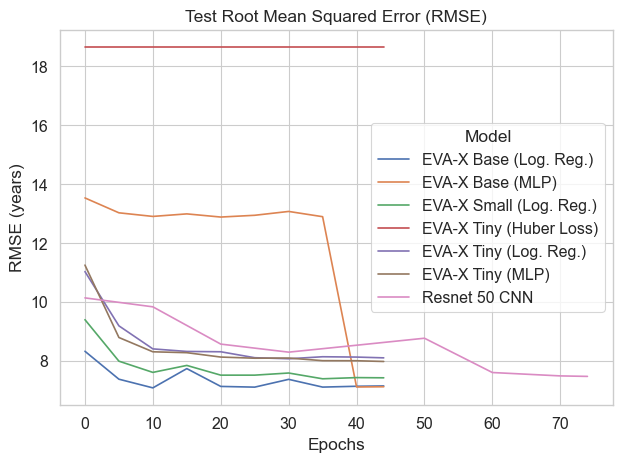

In [51]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)


# MAE
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_rmse",
    hue="Model",
    legend=True,
    errorbar=None
)
plt.title("Test Root Mean Squared Error (RMSE)")
plt.ylabel("RMSE (years)")
plt.xlabel("Epochs")

plt.tight_layout()
plt.savefig("rmse.pdf", dpi=300, bbox_inches="tight")
plt.savefig("rmse.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
def get_model_summary(group):
    # Sort by epoch to ensure we get the true final row
    group = group.sort_values('epoch')
    
    final_row = group.iloc[-1]
    best_row = group.loc[group['test_mae'].idxmin()]
    
    return pd.Series({
        'Final_MAE': final_row['test_mae'],
        'Best_MAE': best_row['test_mae'],
        'Final_RMSE': final_row['test_rmse'],
        'Best_RMSE': best_row['test_rmse'],
        'Best_Epoch_MAE': best_row['epoch']
    })

# Apply the function to each model group
summary_df = df_all.groupby('Model').apply(get_model_summary).sort_values('Best_MAE').reset_index()

summary_df

,Model,Final_MAE,Best_MAE,Final_RMSE,Best_RMSE,Best_Epoch_MAE
0,EVA-X Base (Log. Reg.),4.710198,4.653549,7.142091,7.076851,10.0
1,EVA-X Base (MLP),4.695697,4.686560,7.114594,7.106797,40.0
2,EVA-X Small (Log. Reg.),4.928630,4.895573,7.418722,7.385031,35.0
3,Resnet 50 CNN,4.957842,4.957842,7.466759,7.466759,74.0
4,EVA-X Tiny (MLP),5.388663,5.388663,7.973683,7.973683,44.0
5,EVA-X Tiny (Log. Reg.),5.492207,5.466932,8.096735,8.065933,30.0
6,EVA-X Tiny (Huber Loss),14.370979,14.370950,18.662854,18.662852,0.0
